# Spotify listening history stats

Loads the tables built by `scripts/sync_database.py` and summarizes the Spotify listening history.

The analysis covers:

* Listening activity over time
* Most played artists, albums, and songs
* Temporal listening patterns
* Platform usage
* Playback patterns

The data is loaded from the tables created by `scripts/sync_database.py`. The notebook only reads from the database; it does not use the original JSON files or modify the database.

## Setup

In [1]:
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir():
            return parent
    raise RuntimeError("Could not locate project root (a parent directory containing 'src/')")


project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import validate
from src.database import create_engine_connection

validate()
engine = create_engine_connection()


### Load tables

In [3]:
users = pd.read_sql_table("users", engine)
artists = pd.read_sql_table("artists", engine)
albums = pd.read_sql_table("albums", engine)
songs = pd.read_sql_table("songs", engine)
platforms = pd.read_sql_table("platforms", engine)
listens = pd.read_sql_table("listens", engine)

for name, df in [
    ("users", users), ("artists", artists), ("albums", albums),
    ("songs", songs), ("platforms", platforms), ("listens", listens),
]:
    print(f"{name:<10} {len(df):>10,} rows")


users               1 rows
artists         8,490 rows
albums         18,144 rows
songs          37,810 rows
platforms          20 rows
listens       306,066 rows


## Build a unified listening-history table

Joins `listens` up through `songs` / `albums` / `artists` and out to
`platforms` / `users`, so every row is one listen with its full context
attached. Each table's `name` column is renamed before joining so they
don't collide (`song_name`, `album_name`, `artist_name`).


In [4]:
songs_r = songs.rename(columns={"name": "song_name"})
albums_r = albums.rename(columns={"name": "album_name"})
artists_r = artists.rename(columns={"name": "artist_name"})

history = (
    listens
    .merge(songs_r, on="song_id")
    .merge(albums_r, on="album_id")
    .merge(artists_r, on="artist_id")
    .merge(platforms, on="platform_id")
    .merge(users, on="user_id")
)

history["minutes_played"] = history["ms_played"] / 1000 / 60

history.head()


,listen_id,song_id,platform_id,ts,ms_played,conn_country,ip_addr,reason_start,reason_end,shuffle,...,album_id,song_name,spotify_track_uri,artist_id,album_name,artist_name,user_id,platform,username,minutes_played
0,1,1,1,2015-01-04 00:25:14,190960,IT,151.48.146.65,clickrow,trackdone,0,...,1,Kingston Town,spotify:track:6cOrnBtY3jN76BQpYTiD8v,1,Escape From Babylon To The Kingdom Of Zion,Alborosie,1,"iOS 8.1.2 (iPhone4,1)",Andrea,3.182667
1,2,2,1,2015-01-04 00:28:37,203493,IT,151.48.146.65,trackdone,trackdone,1,...,2,Rastafari Anthem,spotify:track:7CrAKyg7NuhfSI7LtvePWa,1,Rastafari Anthem,Alborosie,1,"iOS 8.1.2 (iPhone4,1)",Andrea,3.391550
2,3,3,1,2015-01-04 00:32:27,229066,IT,151.48.146.65,trackdone,trackdone,1,...,3,Rock The Dancehall,spotify:track:2dePsNPukZ3fqikLNieXvk,1,Sound The System,Alborosie,1,"iOS 8.1.2 (iPhone4,1)",Andrea,3.817767
3,4,4,1,2015-01-04 00:36:28,240893,IT,151.48.146.65,trackdone,trackdone,1,...,3,Play Fool [To Catch Wise],spotify:track:5dbVRCh0tXEIRJWSI0uen1,1,Sound The System,Alborosie,1,"iOS 8.1.2 (iPhone4,1)",Andrea,4.014883
4,5,5,1,2015-01-04 00:39:47,198146,IT,151.48.146.65,trackdone,trackdone,1,...,1,Real Story,spotify:track:09lCCz4rOMk1dGGOWeKZ7s,1,Escape From Babylon To The Kingdom Of Zion,Alborosie,1,"iOS 8.1.2 (iPhone4,1)",Andrea,3.302433


## Overview

In [5]:
total_listens = len(history)
total_hours = history["ms_played"].sum() / 1000 / 60 / 60
start, end = history["ts"].min(), history["ts"].max()

print(f"Total listens:        {total_listens:,}")
print(f"Total listening time: {total_hours:,.1f} hours")
print(f"Date range:           {start.date()} to {end.date()}")
print(f"Unique artists:       {history['artist_id'].nunique():,}")
print(f"Unique albums:        {history['album_id'].nunique():,}")
print(f"Unique songs:         {history['song_id'].nunique():,}")
print(f"Users:                {', '.join(users['username'])}")


Total listens:        306,066
Total listening time: 13,322.5 hours
Date range:           2015-01-04 to 2025-04-23
Unique artists:       8,490
Unique albums:        18,132
Unique songs:         37,810
Users:                Andrea


## Listening activity over time

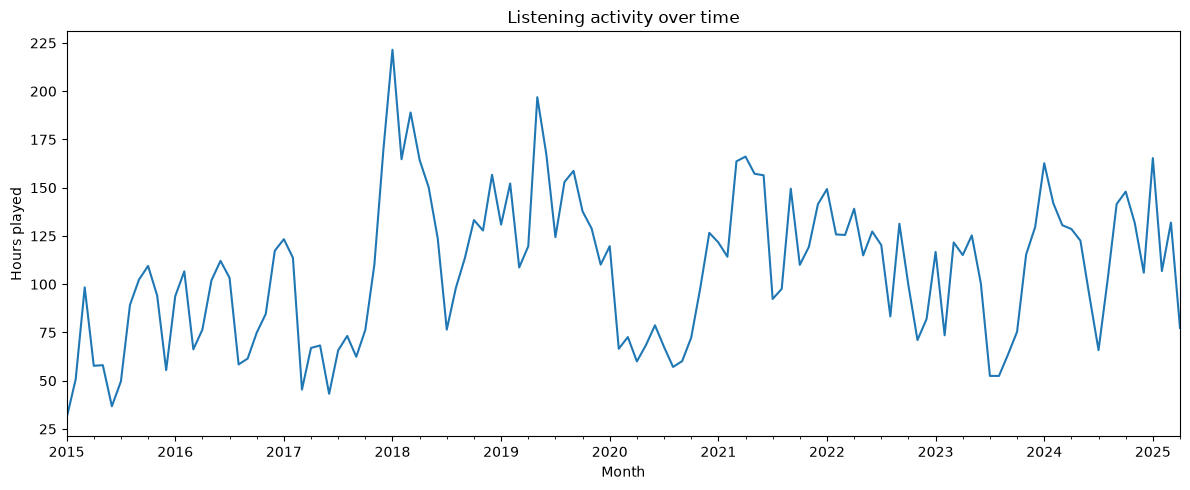

In [6]:
monthly_hours = (
    history.set_index("ts")
    .resample("MS")["ms_played"]
    .sum()
    .div(1000 * 60 * 60)
)

fig, ax = plt.subplots(figsize=(12, 5))
monthly_hours.plot(ax=ax)
ax.set_ylabel("Hours played")
ax.set_xlabel("Month")
ax.set_title("Listening activity over time")
plt.tight_layout()
plt.show()


## Most played artists

By total listening time rather than raw play count, so a handful of long
tracks don't outrank an artist with many short, frequently-replayed ones.


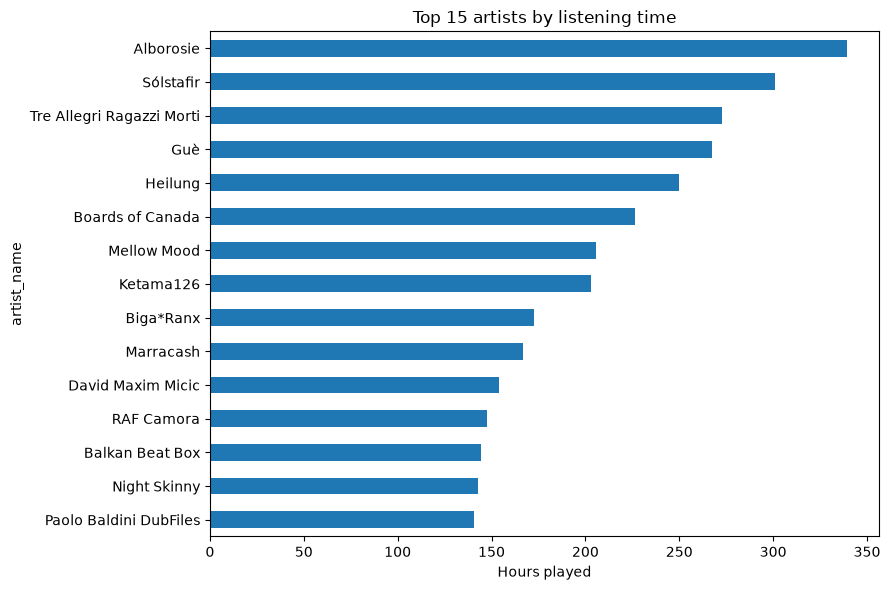

In [7]:
top_artists = (
    history.groupby("artist_name")["ms_played"]
    .sum()
    .div(1000 * 60 * 60)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
top_artists.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Hours played")
ax.set_title("Top 15 artists by listening time")
plt.tight_layout()
plt.show()


## Most played albums

In [8]:
top_albums = (
    history.groupby(["album_name", "artist_name"])["ms_played"]
    .sum()
    .div(1000 * 60 * 60)
    .sort_values(ascending=False)
    .head(15)
)

top_albums


album_name                       artist_name           
Svartir Sandar                   Sólstafir                 180.556790
Futha                            Heilung                   110.841949
Paolo Baldini DubFiles           Paolo Baldini DubFiles     90.874825
Eco                              David Maxim Micic          80.093356
Mattoni                          Night Skinny               79.863851
OBE                              MACE                       78.192342
Music Has The Right To Children  Boards of Canada           75.003930
Santeria                         Marracash                  73.494179
1988                             Biga*Ranx                  66.288303
Ótta                             Sólstafir                  64.487659
Zukunft 1 & 2                    RAF Camora                 63.599148
Tomorrow's Harvest               Boards of Canada           63.156888
Mr. Fini                         Guè                        57.925407
Sound The System Showcase        A

## Most played songs

By play count here, since a song's own length doesn't vary between
listens the way an artist's catalogue does.


In [9]:
top_songs = (
    history.groupby(["song_name", "artist_name"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .rename("play_count")
)

top_songs


song_name                                                   artist_name 
Salvador Dalì                                               Marracash       442
Fahrenheit                                                  Quentin40       340
Taxi                                                        Bonez MC        326
Blaues Licht                                                RAF Camora      322
Zeltron 6 Billion                                           Denzel Curry    305
Scusa                                                       RAF Camora      304
Casablanca (feat. Morad)                                    Baby Gang       295
My Face                                                     Biga*Ranx       286
Leaves of Yggdrasil                                         Myrkur          285
Djákninn                                                    Sólstafir       280
Envidioso (feat. Morad)                                     Capo Plaza      278
Street Advisor (feat. Noyz Narcos, Marracash & 

## Temporal listening patterns

When listens happen across the week, with hour of day (columns) by day of
week (rows).

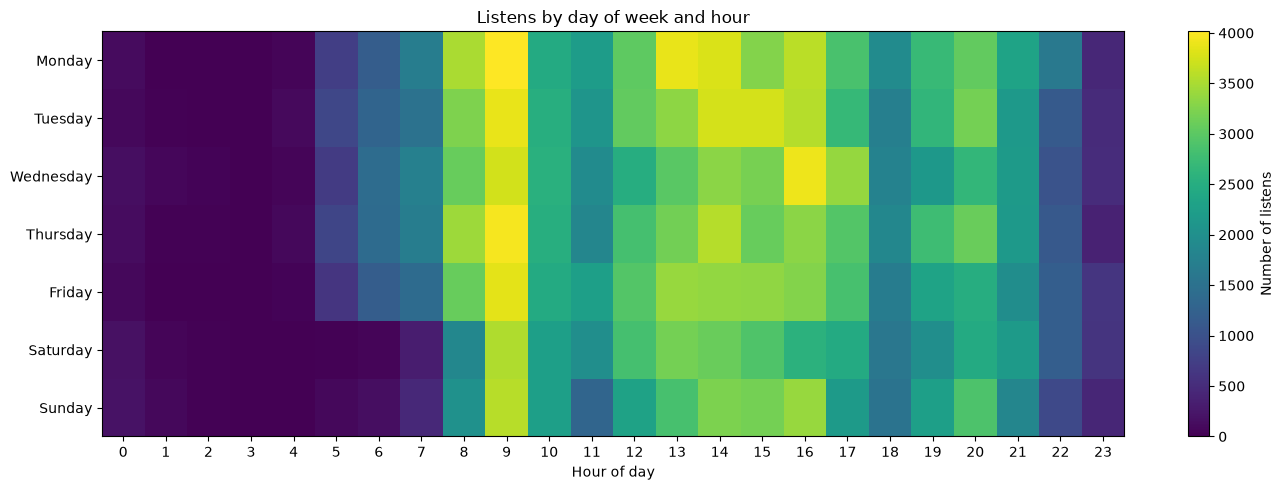

In [10]:
history["hour"] = history["ts"].dt.hour
history["weekday"] = history["ts"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]

heatmap_data = (
    history.groupby(["weekday", "hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)
ax.set_xticks(range(24))
ax.set_xlabel("Hour of day")
ax.set_title("Listens by day of week and hour")
fig.colorbar(im, ax=ax, label="Number of listens")
plt.tight_layout()
plt.show()


## Platform usage

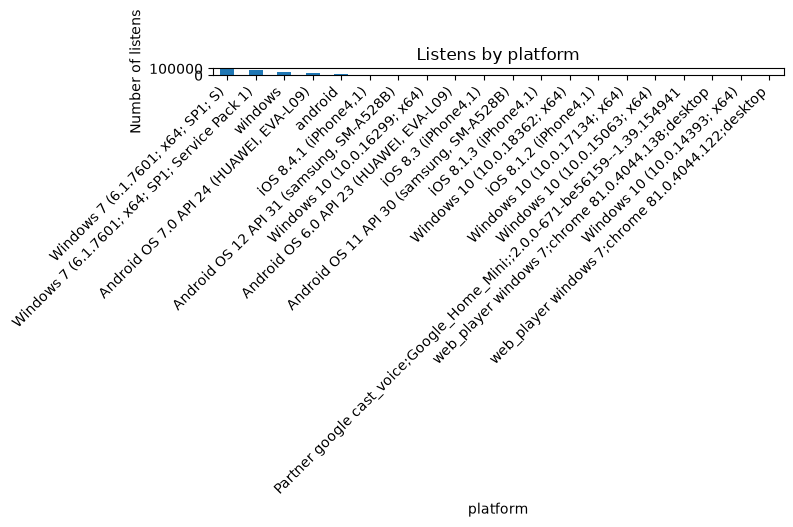

In [11]:
platform_counts = history["platform"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
platform_counts.plot.bar(ax=ax)
ax.set_ylabel("Number of listens")
ax.set_title("Listens by platform")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Playback patterns

`shuffle` / `skipped` / `offline` / `incognito_mode` come back from MySQL
as `0`/`1`, so `.mean()` directly gives the rate.


In [12]:
rates = history[["shuffle", "skipped", "offline", "incognito_mode"]].mean() * 100

for col, pct in rates.items():
    print(f"{col:<16} {pct:5.1f}%")


shuffle            3.7%
skipped            9.5%
offline            0.1%
incognito_mode     0.4%


### Skip reasons

`reason_end` records why a track stopped. `trackdone` is a full listen;
anything else is some form of skip or interruption.


In [13]:
reason_end_counts = history["reason_end"].value_counts(normalize=True).mul(100).round(1)
reason_end_counts


reason_end
trackdone                       65.2
endplay                         24.3
fwdbtn                           6.2
unexpected-exit-while-paused     1.6
logout                           1.1
backbtn                          0.5
remote                           0.4
unexpected-exit                  0.2
clickrow                         0.2
unknown                          0.1
trackerror                       0.1
                                 0.0
popup                            0.0
clickside                        0.0
Name: proportion, dtype: float64